# EDA

In [3]:
%load_ext autoreload
%autoreload 2
import medmnist
import torch 
import random 
import numpy as np
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm
from torchinfo import summary

In [4]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 64
EPOCHS_MLP = 10
EPOCHS_CNN = 40
EPOCHS_VIT = 10
LEARNING_RATE = 1e-3
LEARNING_RATE_VIT = 1e-3

In [5]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [7]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [8]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [9]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [10]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


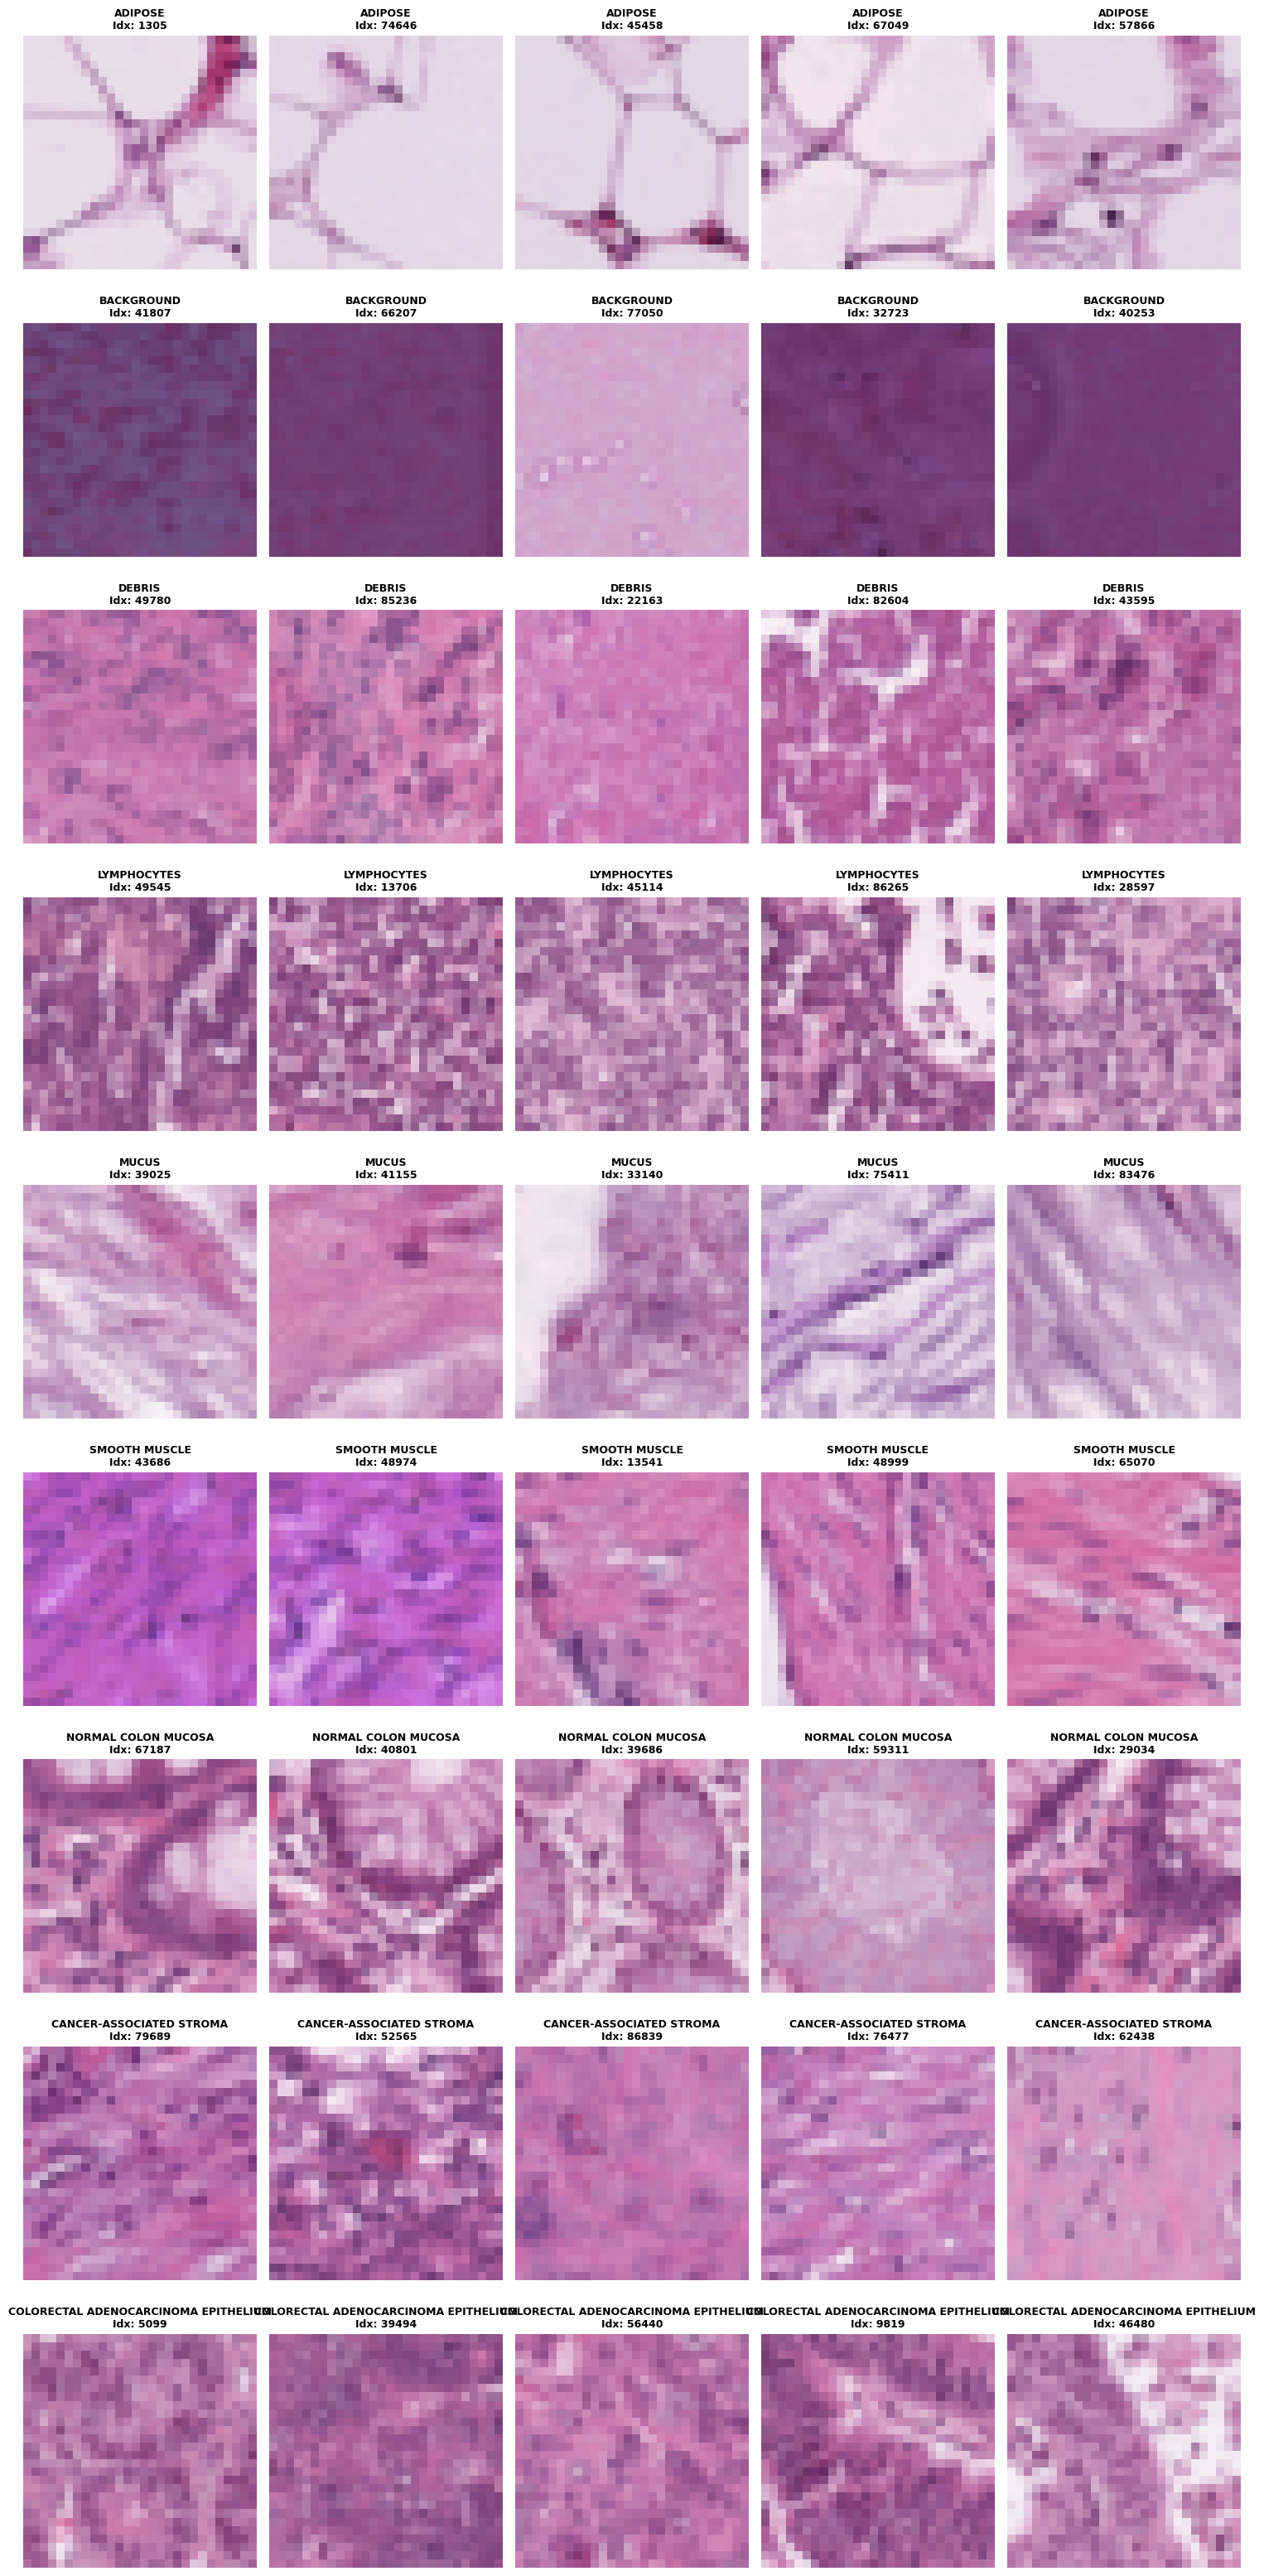

In [11]:
display_medmnist_samples(dataset,"*",5)

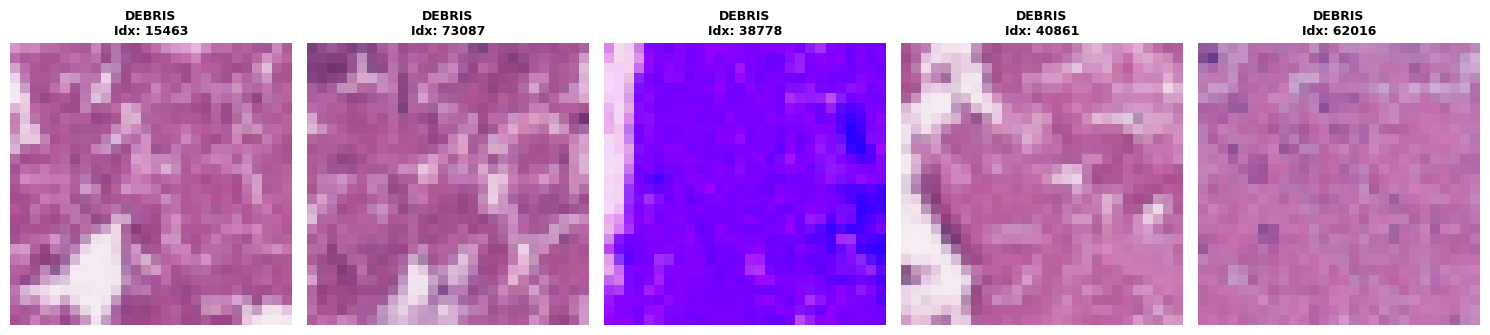

In [12]:
display_medmnist_samples(dataset,"debris",5)

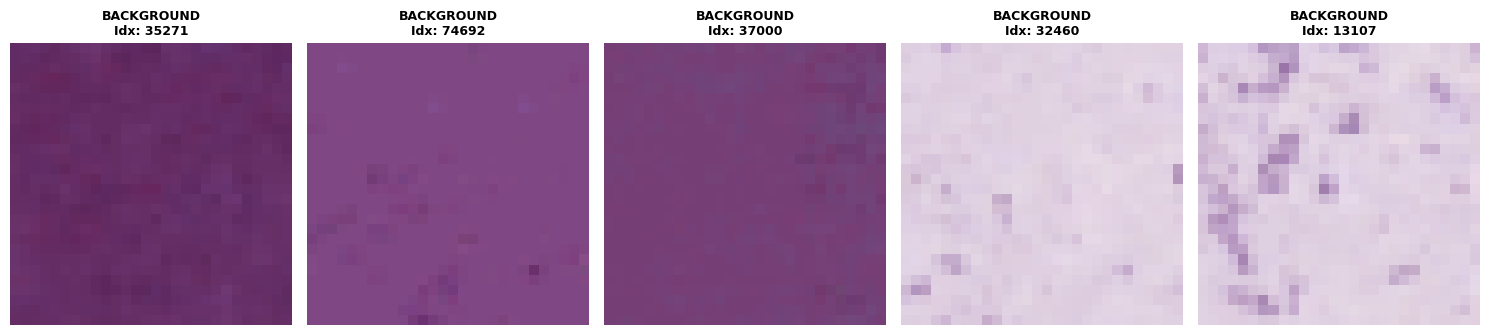

In [13]:
display_medmnist_samples(dataset,"background",5)

Q1.1 - Visual analysis highlights a clear structural divergence: 'Debris' samples exhibit significant spatial heterogeneity and higher chromatic variance, characterized by bright regions and granular textures with high contrast. Conversely, 'Background' samples appear monochromatic and homogeneous, lacking defined structures and showing a much narrower dynamic range in both luminance and saturation.

In [14]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [15]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


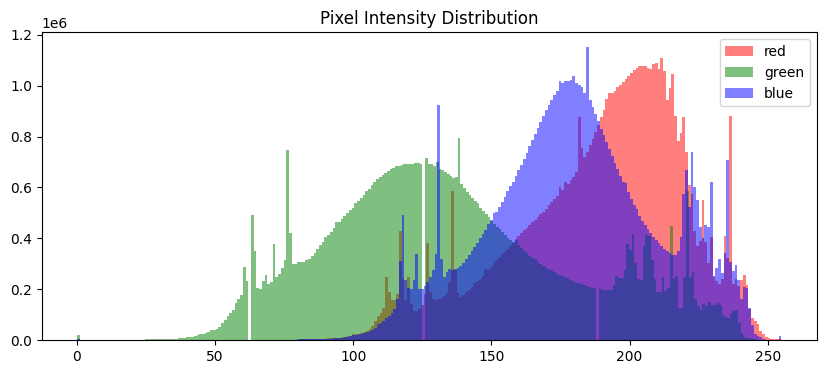

In [16]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Shape: (28, 28, 3)
Red   Channel -> Mean: 128.48 | Std: 10.92
Green Channel -> Mean: 71.84 | Std: 7.18
Blue  Channel -> Mean: 125.65 | Std: 9.77
Global Stats -> Min: 11 | Max: 139


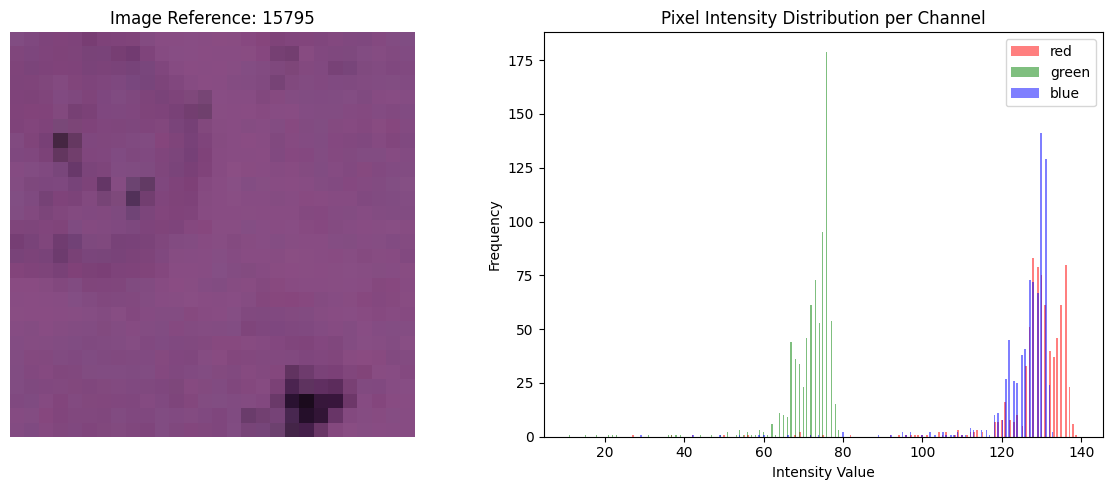

In [17]:
show_random_pixel_stats(dataset)

For this analysis, we have selected a random image from the training set (Index: 15795, Seed: 42). The image is a $28 \times 28 \times 3$ RGB tensor.

**The pixel intensity statistics for this specific sample (on a scale of 0 to 255) are as follows:** \
Red Channel $\rightarrow$ Mean: $128.48$ ($\approx 0.504$) | Std: $10.92$ ($\approx 0.043$) \
Green Channel $\rightarrow$ Mean: $71.84$ ($\approx 0.282$) | Std: $7.18$ ($\approx 0.028$) \
Blue Channel $\rightarrow$ Mean: $125.65$ ($\approx 0.493$) | Std: $9.77$ ($\approx 0.038$) \
Global Mean ($\mu$): $108.66$ (Normalized: $0.426$) \
Global Standard Deviation ($\sigma$): $27.71$ (Normalized: $0.108$) \
Dynamic Range: Min: $11$ / Max: $139$ (Normalized: $0.043$ / $0.545$) 

**ImageNet statistics are the standard benchmark for natural image datasets, usually defined as:** \
ImageNet Mean: $\approx [0.485, 0.456, 0.406]$ (Average $\approx 0.449$) \
ImageNet Std: $\approx [0.229, 0.224, 0.225]$ (Average $\approx 0.226$)

The statistical analysis reveals a significant color bias and low contrast within the sample. The high mean values in the Red ($0.504$) and Blue ($0.493$) channels, compared to the much lower Green channel ($0.282$), quantitatively confirm the pink/purple H&E staining observed visually. Furthermore, the standard deviation per channel is remarkably low (ranging from $0.028$ to $0.043$) compared to ImageNet's average of $0.226$. This indicates that the pixels are highly concentrated around a specific hue with very little brightness variation, which is characteristic of the homogeneous background regions in histopathology images.

# Preparing the data

In [18]:
transform_train = transforms.Compose([
    # 1. Random data augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    
    # 2. Tensor conversion
    transforms.ToTensor(),
    
    # 3. ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [19]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform_train, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_test, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_test, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [18]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.2): # Dropout réduit
        super(MLP, self).__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size) # BatchNorm
        
        # Layer 2 (Option: hidden_size // 2 for funnel effect)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        # Output layer
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        # Bloc 1
        x = self.fc1(x)
        x = self.bn1(x) # Normalise avant l'activation
        x = F.relu(x)
        x = self.dropout(x)
        
        # Bloc 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Sortie (Pas de ReLU ni de Dropout ici !)
        return self.fc3(x)

In [19]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [22]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()
            
            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)
        
        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")
        
    return history

In [23]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS_MLP, device)

Epoch 1/10: 100%|██████████| 1407/1407 [00:10<00:00, 135.88it/s, loss=0.586]


Summary Epoch 1: Val Loss: 0.9263 | Val Acc: 65.47%


Epoch 2/10: 100%|██████████| 1407/1407 [00:10<00:00, 140.55it/s, loss=1.05] 


Summary Epoch 2: Val Loss: 0.8597 | Val Acc: 67.90%


Epoch 3/10: 100%|██████████| 1407/1407 [00:10<00:00, 139.87it/s, loss=0.726]


...

Summary Epoch 8: Val Loss: 0.7843 | Val Acc: 70.11%


Epoch 9/10: 100%|██████████| 1407/1407 [00:10<00:00, 138.54it/s, loss=0.758]


Summary Epoch 9: Val Loss: 0.7753 | Val Acc: 70.06%


Epoch 10/10: 100%|██████████| 1407/1407 [00:10<00:00, 136.91it/s, loss=0.714]


Summary Epoch 10: Val Loss: 0.7600 | Val Acc: 71.39%


Test accuracy:
0.647075208913649
Confusion matrix:
[[1293   11    4    0    2   24    0    0    4]
 [   0  847    0    0    0    0    0    0    0]
 [   0    9  128    0    0  176    0   26    0]
 [  82    4   19  336    1    0   27    0  165]
 [ 154  342    1   20  475    2   30    2    9]
 [   0   62  255    0    1  262    0   11    1]
 [  30    1   18   12   30   12  276    0  362]
 [   1    6  160    0    8   61    7  133   45]
 [   8   11  178    8   16    7  106    3  896]]


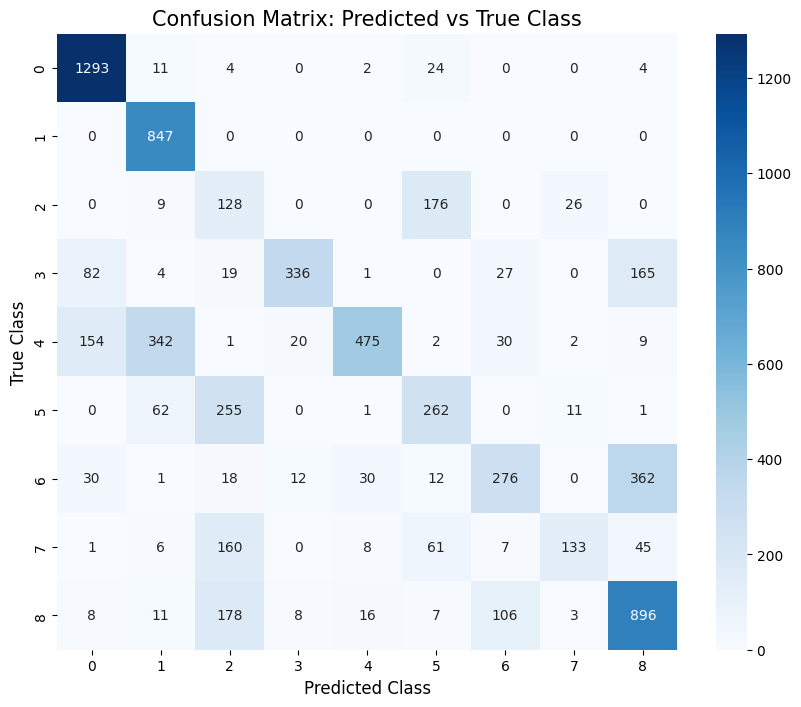

In [24]:
test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:")
print("="*20)
print(test_acc[0])
print("Confusion matrix:")
print("="*20)
print(test_acc[1])
# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names);

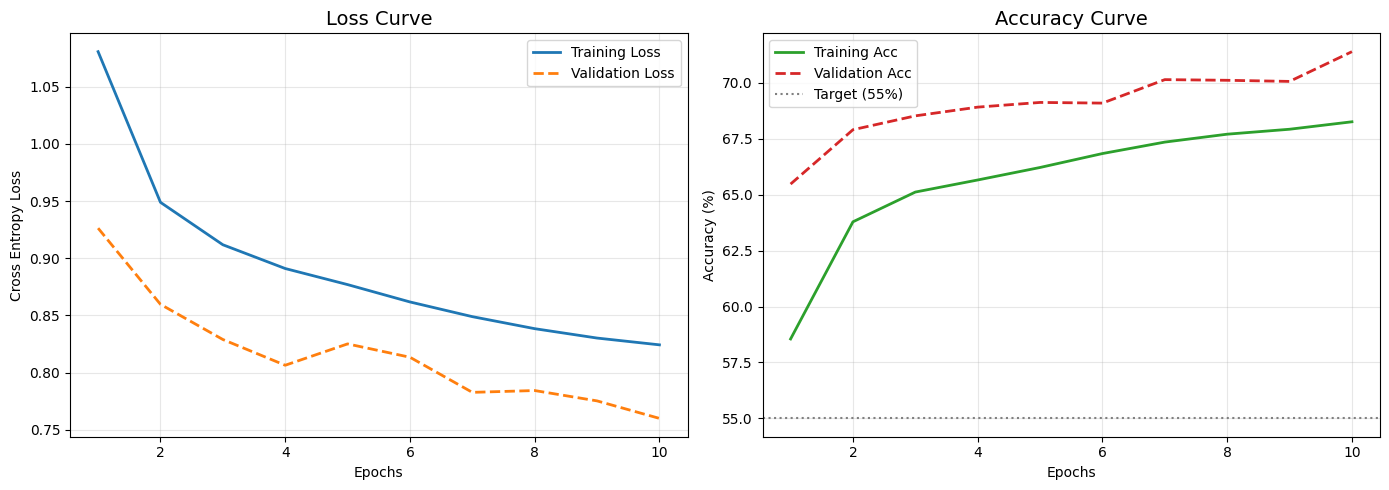

In [25]:
plot_training_history(history)

In [26]:
evaluate_test_accuracy(baseline, test_loader, device)

64.70752089136491

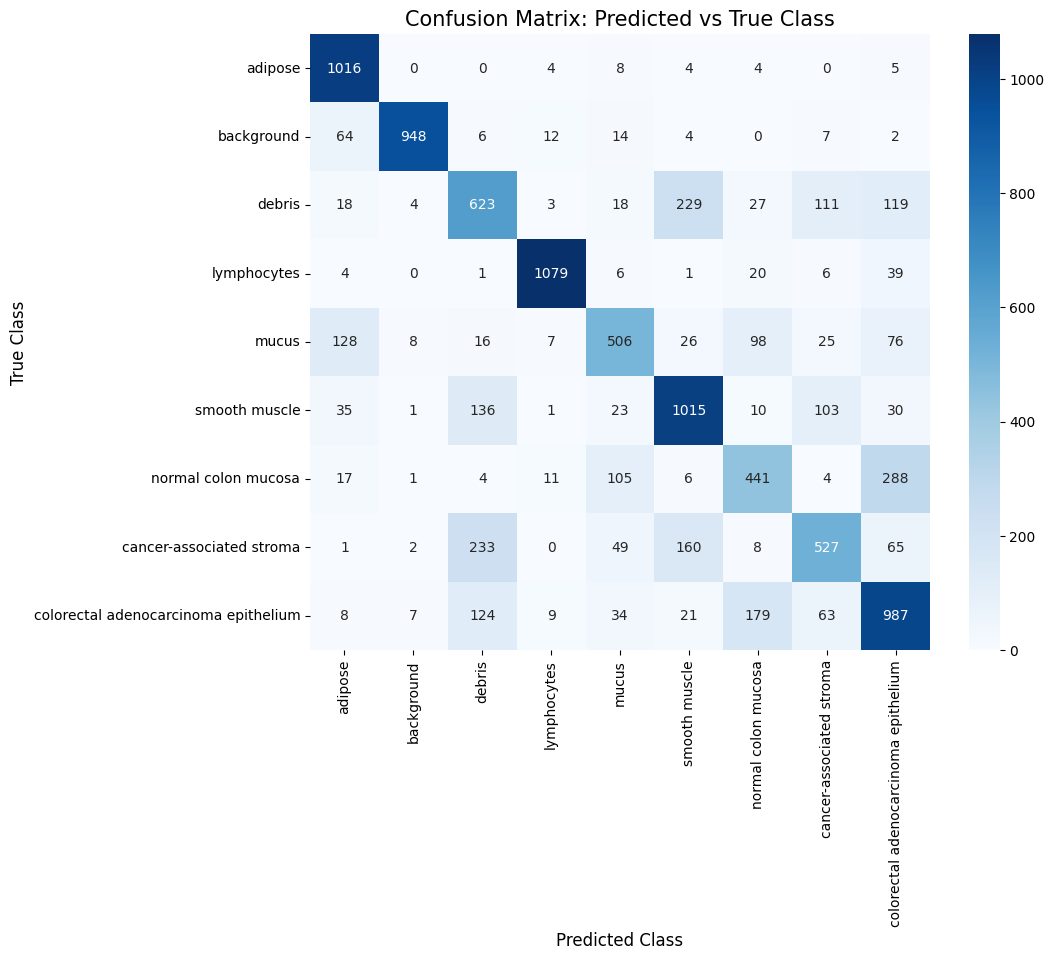

In [27]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [28]:
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — final epoch:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — final epoch:", history["val_acc"][-1])

Train acc — epoch 1: 58.55038001688964
Train acc — epoch 10: 68.25747811013822
Train acc — final epoch: 68.25747811013822
Val acc — epoch 1: 65.47381047580967
Val acc — epoch 10: 71.39144342263094
Val acc — final epoch: 71.39144342263094


In [29]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

In [30]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

Highest Misclassification: 288 instances
True Class: normal colon mucosa (Index 6)
Predicted as: colorectal adenocarcinoma epithelium (Index 8)


The highest misclassification occurs between True Class: "normal colon mucosa" and Predicted Class: "colorectal adenocarcinoma epithelium" with 404 cases.

This is likely due to:

Structural Similarity: Both are epithelial tissues with similar cell membranes and nuclear densities.

Morphological Overlap: Normal glands can appear irregular or "tumor-like" depending on the tissue cut, confusing the model.

MLP Limitations: Unlike CNNs, MLPs focus on pixel intensity rather than spatial patterns, making it hard to distinguish organized healthy glands from disorganized cancerous ones.

# CNN

In [33]:
class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

CNNFromScratch(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.3, inplace=False)
  )
  (gap): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_fea

In [ ]:
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Params of the first conv layer
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# PyTorch check
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    cnn,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=EPOCHS_CNN,
    device=device
)

Epoch 1/40: 100%|██████████| 1407/1407 [00:11<00:00, 124.70it/s, loss=0.969]


Summary Epoch 1: Val Loss: 0.7439 | Val Acc: 74.31%


Epoch 2/40: 100%|██████████| 1407/1407 [00:10<00:00, 128.95it/s, loss=0.832]


Summary Epoch 2: Val Loss: 0.5916 | Val Acc: 79.66%


Epoch 3/40: 100%|██████████| 1407/1407 [00:10<00:00, 128.61it/s, loss=0.559]


...

Summary Epoch 38: Val Loss: 0.2488 | Val Acc: 91.96%


Epoch 39/40: 100%|██████████| 1407/1407 [00:10<00:00, 130.11it/s, loss=0.556]


Summary Epoch 39: Val Loss: 0.2330 | Val Acc: 92.48%


Epoch 40/40: 100%|██████████| 1407/1407 [00:10<00:00, 129.98it/s, loss=0.524]


Summary Epoch 40: Val Loss: 0.2416 | Val Acc: 92.24%


In [ ]:
# Q3.1 — First epoch where the gap (train_acc - val_acc) exceeds 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs start at 1
        break

print("First epoch with gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc :", history_cnn["train_acc"][i])
    print("Val acc :", history_cnn["val_acc"][i])
    print("Gap :", gaps[i])
else:
    print("No epoch where train_acc - val_acc > 15 over these", EPOCHS_CNN, "epochs.")

Premier epoch avec gap > 15: None
Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.


We trained the CNN for 40 epochs without data augmentation and analyzed the accuracy trends on both the training and validation sets. To detect potential overfitting, we calculated the gap between train_acc and val_acc at each epoch. Throughout the 40 epochs, this difference never exceeded 15 percentage points. This suggests that the model does not exhibit significant overfitting in this configuration and generalizes relatively well to the validation data.

CNN TEST accuracy: 0.871866295264624


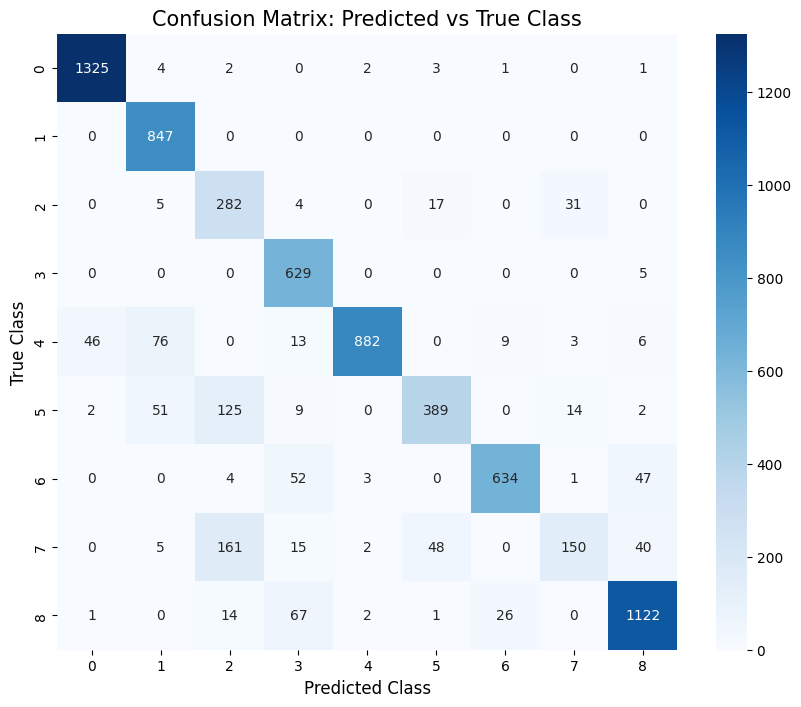

array([[1325,    4,    2,    0,    2,    3,    1,    0,    1],
       [   0,  847,    0,    0,    0,    0,    0,    0,    0],
       [   0,    5,  282,    4,    0,   17,    0,   31,    0],
       [   0,    0,    0,  629,    0,    0,    0,    0,    5],
       [  46,   76,    0,   13,  882,    0,    9,    3,    6],
       [   2,   51,  125,    9,    0,  389,    0,   14,    2],
       [   0,    0,    4,   52,    3,    0,  634,    1,   47],
       [   0,    5,  161,   15,    2,   48,    0,  150,   40],
       [   1,    0,   14,   67,    2,    1,   26,    0, 1122]])

In [35]:
test_acc_cnn, test_cm_cnn = eval_test(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

The confusion matrix shows that the majority of correct predictions lie on the diagonal, indicating that the CNN correctly classifies a large portion of the images in the test set. Certain classes are recognized almost perfectly, such as Class 1 and Class 3. However, some confusion persists between visually similar classes—for instance, between certain images of Classes 5 and 2, or between Classes 7 and 8. Overall, the results demonstrate that the CNN captures spatial structures in the images better than the previously used MLP model, leading to a significant improvement in classification performance.

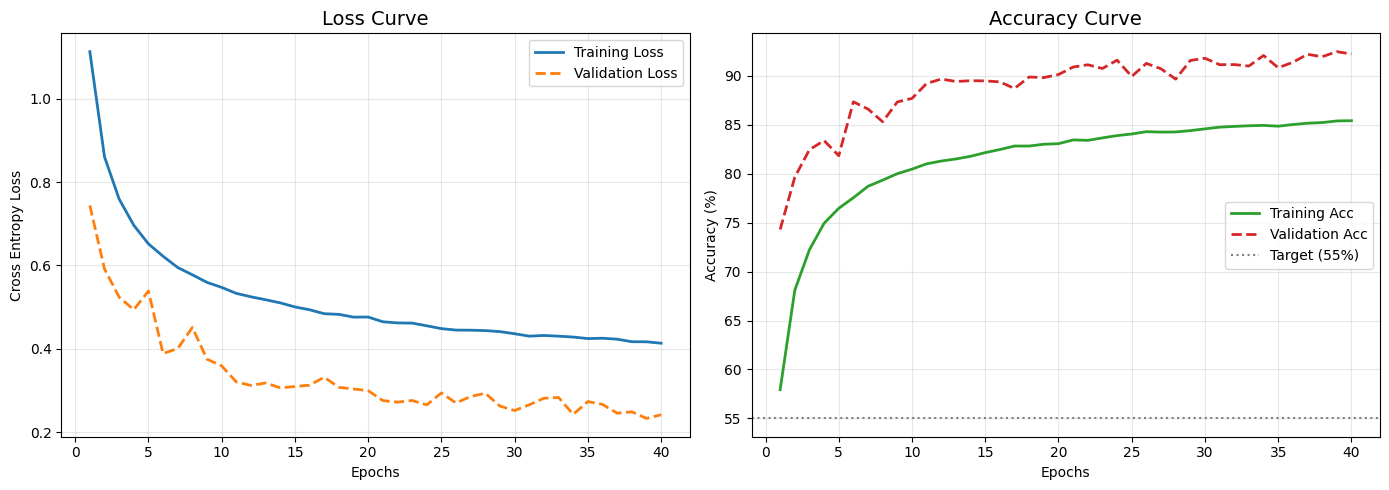

In [36]:
plot_training_history(history_cnn)

# VIT

In [ ]:
class SimpleViT(nn.Module): 
    def __init__(self,img_size=28, patch_size=4, in_channels=3, num_classes=9,embed_dim=128, depth=4, heads=8, mlp_dim=256, pos_enc=True): 
        super().__init__() 

        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2 
        self.patch_dim = in_channels * patch_size ** 2 
        self.patch_size = patch_size
        # 1 PATCH EMBEDDING
        self.patch_embedding = nn.Linear(self.patch_dim, embed_dim)


        # 2 CLS TOKEN AND POSITION EMBEDDING
        # Grabs information from all patches to make the final classification decision. It's a special token that serves as a summary representation of 
        # the entire image after processing through the transformer encoder. 
        # During training, the model learns to use this token to capture relevant features from all patches to make the final classification decision.
        
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)) 


        if pos_enc:
            self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))
        else:
            # Option A: On crée un buffer (tenseur fixe qui ne monte pas dans l'optimiseur)
            self.register_buffer('position_embedding', torch.zeros(1, self.num_patches + 1, embed_dim))

        # 3 TRANSFORMER ENCODER
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=mlp_dim, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        #4 CLASSIFIER HEAD
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self,x):
        p = self.patch_size

        # patches extraction
        
        x = x.unfold(2,p,p).unfold(3,p,p) # 2 and 3 because we unfold on height and width , first p is the patch size and second p is the stride (non-overlapping)
        x = x.permute(0,2,3,1,4,5).contiguous() # Put the color channels after the patch dimensions , permute forces pytorch to copy and rearrange the dimensions and contiguous makes sure the memory layout is correct for the next operations

        x = x.view(x.size(0), self.num_patches, -1) # flatten the patch dimensions and color channels into a single dimension for each patch , -1 to let pytorch infer the correct size based on the remaining dimensions

        x = self.patch_embedding(x) # (B, num_patches, embed_dim)

        b , n , _ = x.shape
        cls_token = self.cls_token.expand(b, -1, -1) # copy the cls token for each sample in the batch , -1 means we keep the same size for that dimension
        x = torch.cat((cls_token, x), dim=1) # concatenate the cls token to the patch embeddings
        x = x + self.position_embedding # add the position embedding to the input sequence

        x = self.transformer_encoder(x) # (B, num_patches + 1, embed_dim)

        return self.mlp_head(x[:,0]) # we only use the cls token output for classification


Model on device: cuda:0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model = SimpleViT().to(device)
print("Model on device:", next(vit_model.parameters()).device)

In [22]:
criterion_vit = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_model.parameters(), lr=LEARNING_RATE_VIT , weight_decay=0.01) # adamW is a variant of Adam that decouples weight decay from the gradient update, which can lead to better generalization performance in some cases, especially for transformer-based models like ViT. 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_VIT) # CosineAnnealingLR is a learning rate scheduler that adjusts the learning rate following a cosine decay pattern over the course of training. T_max is the number of epochs for one cycle of the cosine decay, meaning that the learning rate will start at the initial value, decrease to a minimum, and then potentially restart if you have multiple cycles. This can help improve convergence and generalization in some cases, especially for transformer-based models like ViT.

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0 

    for inputs, targets in tqdm(loader, desc="Training"): 
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze().long() # Remove extra dimensions and convert to long for CrossEntropyLoss

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0) # Find the total loss
        _, predicted = outputs.max(1) # Get the index of the max log-probability
        total += targets.size(0) # Count the number of seen examples
        correct += predicted.eq(targets).sum().item() # Update correct with the number of correct predictions in the batch, eq returns [True , False , True , True]

    return running_loss / total, 100. * correct / total  # Return average loss and accuracy percentage

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): 
        for inputs, targets in tqdm(loader, desc ="Validation"):
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.squeeze().long() 

            outputs = model(inputs)
            loss = criterion(outputs,targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100. * correct / total




In [23]:
def train_and_evaluate_vit(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Mise à jour du learning rate
        scheduler.step()
        
        # Sauvegarde de l'historique
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    return history

history_baseline_vit = train_and_evaluate_vit(vit_model, train_loader, val_loader, criterion_vit, optimizer, scheduler, EPOCHS_VIT, device)


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 216.66it/s]


Train Loss: 0.9516 | Train Acc: 63.72%
Val Loss: 0.7007 | Val Acc: 74.52%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 217.82it/s]


Train Loss: 0.6149 | Train Acc: 77.21%
Val Loss: 0.5269 | Val Acc: 80.52%

Epoch 3/10


...

Train Loss: 0.2078 | Train Acc: 92.63%
Val Loss: 0.1771 | Val Acc: 93.89%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 213.90it/s]


Train Loss: 0.1765 | Train Acc: 93.69%
Val Loss: 0.1561 | Val Acc: 94.58%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 212.17it/s]

Train Loss: 0.1605 | Train Acc: 94.24%
Val Loss: 0.1483 | Val Acc: 94.76%


In [24]:
def plot_training_history(history):
    plt.plot(history['val_acc'], label='ViT', marker='o')
    plt.plot(history['train_acc'], label='ViT Train', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

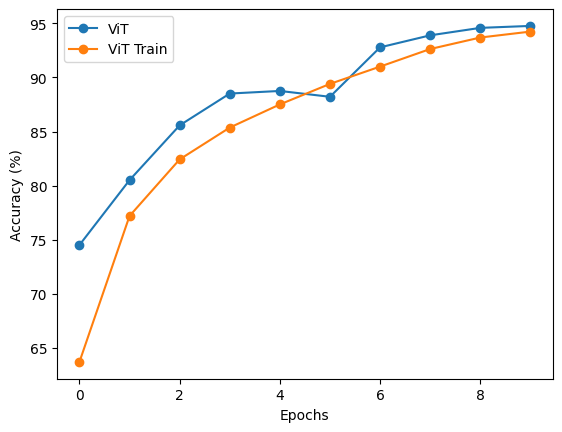

In [25]:
plot_training_history(history_baseline_vit)

**PATCH SIZE 7**

In [26]:
# --- Expérience Patch Size 7 ---
vit_model_7 = SimpleViT(patch_size=7).to(device)
# On crée un optimizer spécifique aux paramètres de vit_model_7
optimizer7 = optim.AdamW(vit_model_7.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler7 = optim.lr_scheduler.CosineAnnealingLR(optimizer7, T_max=EPOCHS_VIT)
print("Starting Training: Patch Size 7")
history_vit7 = train_and_evaluate_vit(vit_model_7, train_loader, val_loader, 
                                     criterion_vit, optimizer7, scheduler7, EPOCHS_VIT, device)

Starting Training: Patch Size 7

Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 220.21it/s]


Train Loss: 1.0328 | Train Acc: 60.46%
Val Loss: 0.9606 | Val Acc: 64.20%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 219.89it/s]


Train Loss: 0.7790 | Train Acc: 70.55%
Val Loss: 0.7184 | Val Acc: 73.62%

Epoch 3/10


...

Train Loss: 0.3411 | Train Acc: 87.56%
Val Loss: 0.2971 | Val Acc: 89.34%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 226.19it/s]


Train Loss: 0.3046 | Train Acc: 88.87%
Val Loss: 0.2811 | Val Acc: 89.83%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 226.57it/s]

Train Loss: 0.2815 | Train Acc: 89.88%
Val Loss: 0.2692 | Val Acc: 90.42%


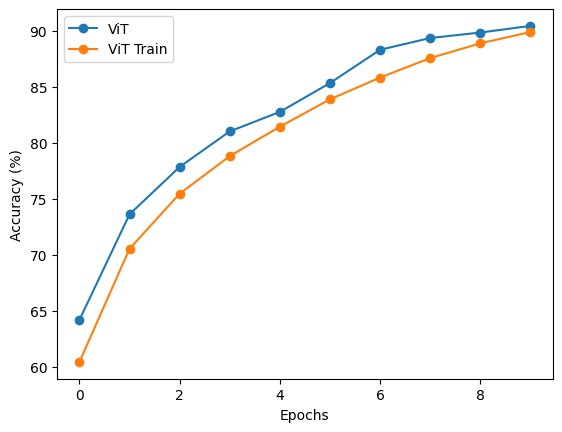

In [27]:
plot_training_history(history_vit7)

**PATCH SIZE 14**

In [28]:
vit_model_14 = SimpleViT(patch_size=14).to(device)
# On crée un optimizer spécifique aux paramètres de vit_model_14
optimizer14 = optim.AdamW(vit_model_14.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler14 = optim.lr_scheduler.CosineAnnealingLR(optimizer14, T_max=EPOCHS_VIT)
print("Starting Training: Patch Size 14")
history_vit14 = train_and_evaluate_vit(vit_model_14, train_loader, val_loader, 
                                      criterion_vit, optimizer14, scheduler14, EPOCHS_VIT, device)

Starting Training: Patch Size 14

Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 222.56it/s]


Train Loss: 1.2034 | Train Acc: 53.83%
Val Loss: 1.0445 | Val Acc: 59.55%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 222.93it/s]


Train Loss: 0.9725 | Train Acc: 62.65%
Val Loss: 0.9370 | Val Acc: 63.12%

Epoch 3/10


...

Train Loss: 0.6766 | Train Acc: 73.99%
Val Loss: 1.4616 | Val Acc: 52.03%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 224.32it/s]


Train Loss: 0.6431 | Train Acc: 75.37%
Val Loss: 2.1156 | Val Acc: 42.61%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 225.08it/s]

Train Loss: 0.6216 | Train Acc: 76.12%
Val Loss: 1.9271 | Val Acc: 45.55%


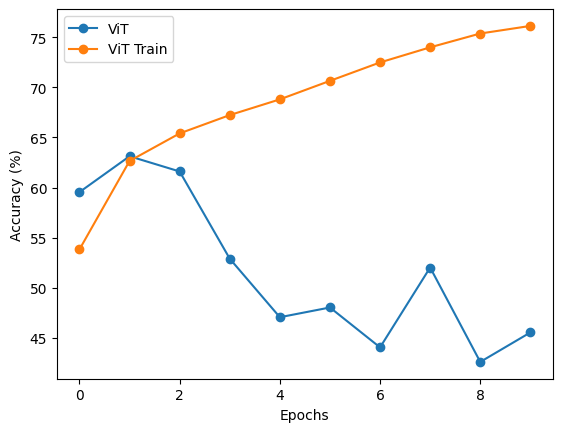

In [29]:
plot_training_history(history_vit14)

Q5.1 - The number of patches is calculated by dividing the total image area by the patch area:$$\text{Number of patches} = \frac{H \times W}{P^2}$$
Where $H, W$ are the image dimensions and $P$ is the patch size.


Case $P = 7$:$$\frac{28 \times 28}{7 \times 7} = \frac{784}{49} = \mathbf{16 \text{ patches}}$$

Case $P = 14$:$$\frac{28 \times 28}{14 \times 14} = \frac{784}{196} = \mathbf{4 \text{ patches}}$$

Concretely, for $P = 14$, the self-attention mechanism would struggle for two main reasons: \
**Extremely Short Sequence Length**: Self-attention is designed to capture complex spatial relationships and long-range dependencies between many elements. With only 4 patches, the attention matrix is just $4 \times 4$. There are almost no "relationships" to learn; the model is essentially looking at four large quadrants, which is too coarse to identify fine biological structures (like the debris or textures we observed earlier). \
**Loss of Local Information**: A patch of $14 \times 14$ is very large relative to a $28 \times 28$ image. By flattening such a large area into a single embedding vector, we lose nearly all the internal spatial arrangement (local texture, edges, and small shapes) within those quadrants.

**Prediction**: The patch size 7 will yield significantly higher accuracy than patch size 14. 

**Justification**: 
1.  Resolution: $P=7$ provides a sequence of 16 tokens, allowing the Transformer to learn the spatial layout of the tissue.
2.  Information Density: Smaller patches preserve more structural detail during the initial linear projection.
3.  Model Capacity: With only 4 tokens ($P=14$), the Transformer layer is "under-utilized" and acts more like a simple MLP than a powerful attention-based feature extractor.

**NO POS ENCODING**

In [30]:
baseline_no_pos_enc = SimpleViT(patch_size=7, pos_enc=False).to(device)
 
optimizer_no_pos = optim.AdamW(baseline_no_pos_enc.parameters(), lr=LEARNING_RATE_VIT, weight_decay=0.01)
scheduler_no_pos = optim.lr_scheduler.CosineAnnealingLR(optimizer_no_pos, T_max=EPOCHS_VIT)

history_no_pos = train_and_evaluate_vit(
    baseline_no_pos_enc, train_loader, val_loader, 
    criterion_vit, optimizer_no_pos, scheduler_no_pos, EPOCHS_VIT, device
)


Epoch 1/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 225.74it/s]


Train Loss: 0.9348 | Train Acc: 64.84%
Val Loss: 0.6387 | Val Acc: 76.49%

Epoch 2/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 225.31it/s]


Train Loss: 0.6722 | Train Acc: 75.21%
Val Loss: 0.5973 | Val Acc: 78.53%

Epoch 3/10


...

Train Loss: 0.3014 | Train Acc: 89.08%
Val Loss: 0.2718 | Val Acc: 90.42%

Epoch 9/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 223.91it/s]


Train Loss: 0.2650 | Train Acc: 90.34%
Val Loss: 0.2280 | Val Acc: 92.05%

Epoch 10/10


Validation: 100%|██████████| 157/157 [00:00<00:00, 220.79it/s]

Train Loss: 0.2432 | Train Acc: 91.20%
Val Loss: 0.2141 | Val Acc: 92.62%


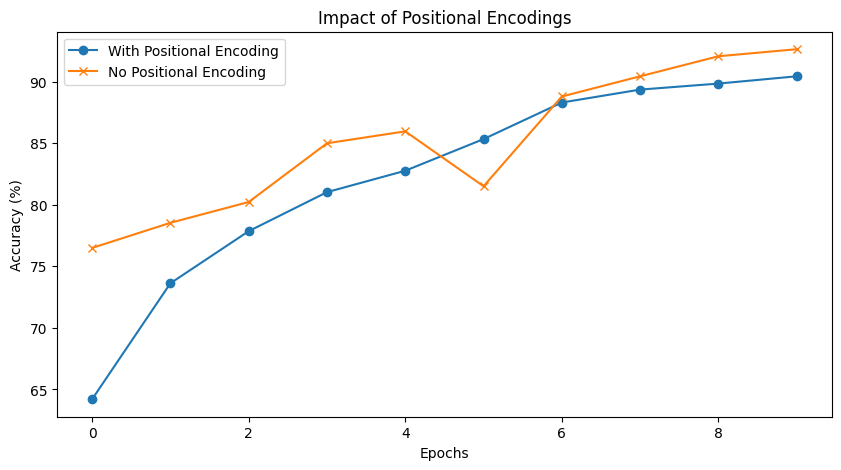

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(history_vit7['val_acc'], label='With Positional Encoding', marker='o')
plt.plot(history_no_pos['val_acc'], label='No Positional Encoding', marker='x')
plt.title("Impact of Positional Encodings")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

**Q5.2 — Impact of Positional Embeddings Removal**
Results Summary (Patch Size = 7):

With Positional Encoding: 90.42% Accuracy

Without Positional Encoding: 92.62% Accuracy

Observed Drop: None (Performance increased by +2.20%)

1. **Theoretical Expectation**

A drop is expected because Transformers are permutation-invariant. Without Positional Embeddings (PE), the model treats the image as a "bag of patches," losing the spatial layout. In standard computer vision, knowing the relative position of features (e.g., eyes above a mouth) is crucial for global object recognition.

2. **Justification for Tissue Classification**

Contrary to theory, performance improved. This is due to:

Spatial Invariance: Histological diagnosis relies on local textures (cell morphology, density) rather than a global fixed architecture. Whether a cancerous cell is at the top or bottom of the slide doesn't change the diagnosis.

Reduced Complexity: PE adds parameters to learn. Removing them simplifies the optimization task, allowing the model to focus immediately on discriminative visual features.

3. **Training Stability Analysis**

Instability with PE: Random initialization (randn) introduces "spatial noise." The model struggles to simultaneously "denoise" positions and learn visual patterns, leading to erratic gradients.

Stability without PE: Using a zero-buffer provides a neutral starting point. This eliminates spatial competition, resulting in a smoother, more robust convergence focused solely on patch content.

**VIT MODEL SUMMARY**

In [36]:
summary(vit_model, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                        Output Shape              Param #
SimpleViT                                     [64, 9]                   6,528
├─Linear: 1-1                                 [64, 49, 128]             6,272
├─TransformerEncoder: 1-2                     [64, 50, 128]             --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-2      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-3      [64, 50, 128]             132,480
│    │    └─TransformerEncoderLayer: 3-4      [64, 50, 128]             132,480
├─Sequential: 1-3                             [64, 9]                   --
│    └─LayerNorm: 2-2                         [64, 128]                 256
│    └─Linear: 2-3                            [64, 9]                   1,161
Total params: 544,137
Trainable params: 544,137
Non-trainable par

**CNN SUMMARY**

In [35]:
summary(cnn, input_size=(BATCH_SIZE, CHANNELS, IMG_SIZE[0], IMG_SIZE[1]))

Layer (type:depth-idx)                   Output Shape              Param #
CNNFromScratch                           [64, 9]                   --
├─Sequential: 1-1                        [64, 32, 14, 14]          --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          896
│    └─BatchNorm2d: 2-2                  [64, 32, 28, 28]          64
│    └─ReLU: 2-3                         [64, 32, 28, 28]          --
│    └─Dropout2d: 2-4                    [64, 32, 28, 28]          --
│    └─MaxPool2d: 2-5                    [64, 32, 14, 14]          --
├─Sequential: 1-2                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-6                       [64, 64, 14, 14]          18,496
│    └─BatchNorm2d: 2-7                  [64, 64, 14, 14]          128
│    └─ReLU: 2-8                         [64, 64, 14, 14]          --
│    └─Dropout2d: 2-9                    [64, 64, 14, 14]          --
│    └─MaxPool2d: 2-10                   [64, 64, 7, 7]            --
├─Sequent

**Q5.3 — Comparison of Parameters: ViT vs. CNN**

Quantitative Comparison:

Total Parameters (ViT): 544,137

Total Parameters (CNN): 94,857

Comparison: The ViT has significantly more parameters than the CNN.Factor: The ViT is approximately 5.7 times larger than the CNN ($544,137 / 94,857 \approx 5.74$).

Despite being nearly 6 times larger, the ViT may underperform the CNN due to the following fundamental reasons:

Lack of Inductive Biases: CNNs possess strong "inductive biases" like locality and translation invariance (they know that pixels close together are related and that a feature is the same regardless of its position). ViTs have much weaker structural priors; they must "learn" how an image is structured from scratch.

Dataset Size Requirements: Because ViTs have less built-in knowledge about images, they are notoriously "data-hungry." On smaller or medium-sized datasets like this one, the CNN's architectural shortcuts allow it to reach high accuracy faster, whereas the ViT may require significantly more data or heavy pre-training to outperform it.

Overfitting Risk: With 5.7x more parameters, the ViT has a much higher capacity to "memorize" the training set rather than generalizing, especially if the number of training samples is limited. The CNN's constrained architecture acts as a natural regularizer.

Input Resolution: For low-resolution images (like $28 \times 28$), the local receptive fields of a CNN are extremely efficient at capturing small-scale patterns. The global attention of a ViT is more powerful for high-resolution, complex scenes where distant relationships matter more, which might not be the case here.